# Data 206 Capstone EDA Project

## Installing libraries

In [ ]:
library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Attaching package: 'lubridate'

The following objects are masked from 'package:base':

    date, intersect, setdiff, union

In [ ]:
Impound <- read.csv("C:/Users/casti/OneDrive/Documents/Data 206 Capstone Project/.quarto/project-cache/Animal Impound.csv")
Shelter <- read.csv("C:/Users/casti/OneDrive/Documents/Data 206 Capstone Project/.quarto/project-cache/Animal Pathway.csv") #Adding the two datasets

In [ ]:
colnames(Impound)[colnames(Impound) == "Animal.identification.number"] <- "Animal.ID"
colnames(Shelter)[colnames(Shelter) == "Animal.identification.number"] <- "Animal.ID" # Changing the name of the column to make it easier
combined <- left_join(Impound,Shelter, by = "Animal.ID") #The merging of the two datasets

Warning in left_join(Impound, Shelter, by = "Animal.ID"): Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 26 of `x` matches multiple rows in `y`.
ℹ Row 21 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.

[1] 5847

 [1] "Impound.number"           "Kennel.number.location"  
 [3] "Animal.ID"                "Animal.source"           
 [5] "Animal.owner"             "jurisdiction"            
 [7] "Impound.type"             "Intake.subcategory"      
 [9] "Impound.date.and.time"    "Release.date"            
[11] "Surrender.reason"         "source"                  
[13] "Total.number.per.impound" "Animal.intake.condition" 
[15] "Animal.control.hold"      "Outcome.type"            
[17] "Outcome.subtype"          "Animal.outcome.condition"
[19] "Departure.date.and.time"  "Animal.name"             
[21] "Animal.type"              "Sex.of.animal"           
[23] "Pet.s.age.in.years"       "Pet.s.age.in.months"     
[25] "Pet.s.date.of.birth"      "Pet.s.age"               
[27] "Bite.history"             "Animal.size"             
[29] "Color.of.animal"          "Breed.of.animal"         
[31] "Collar.present"          

In [ ]:
monthly_outcomes <- Year_month %>%
  filter(!is.na(Departure.date.and.time)) %>% # making sure there is no NAs 
  group_by(YearMonth, Outcome.type.y) %>% # To create a group for each month for each outcome
  summarise(count = n(), .groups = "drop") #To make each outcome a new row for each month

  

# These graphs could possibly supplement my tableau map

## First Graph for Project - Are certain times of the year associated with higher intake rates?​

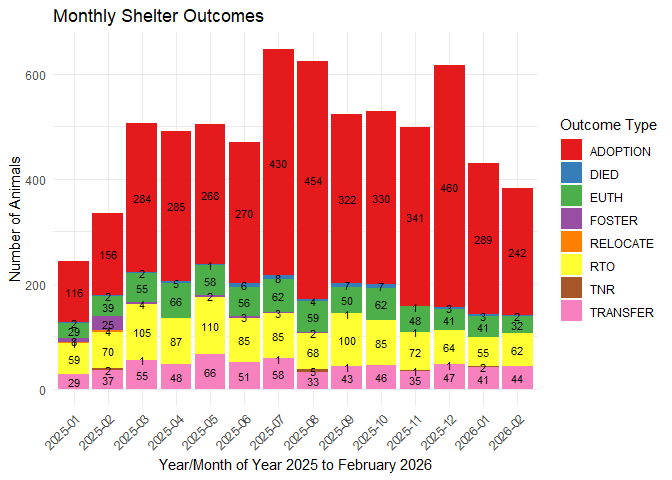

In [ ]:
ggplot(monthly_outcomes, aes(x = YearMonth, y = count, fill = Outcome.type.y)) +
  geom_bar(stat = "identity") + # Make sure that it uses the counts from montly income
  theme_minimal() + # Add theme to my graph
   geom_text(aes(label = count),
            position = position_stack(vjust = 0.5), # This will center my count in the middle of each stack
            size = 3,
            color = "black") +
  scale_fill_brewer(palette = "Set1")  + 
  labs(
    title = "Monthly Shelter Outcomes",
    x = "Year/Month of Year 2025 to February 2026",
    y = "Number of Animals",
    fill = "Outcome Type"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # This makes it possible so the x labels don't overlap

## Creating second data frame for my next graph

In [ ]:
Euthanized <- combined %>%
  filter(Outcome.type.y == "EUTH") #Filter for Euthanization

Euthanized <- Euthanized %>%
  filter(!is.na(Age_Year)) #Remove any NAs
Euthanized <- Euthanized %>%
  mutate(
    Age_group = case_when(
     Age_Year < 1 ~ "Under 1", # Create age groups as every number will be hard to graph
      Age_Year >= 1 & Age_Year < 3 ~ "1-3 Age group",
      Age_Year >= 3 & Age_Year < 7 ~ "3-7 Age group",
      Age_Year >= 7& Age_Year < 10 ~ "7-10 Age group",
      Age_Year > 10 ~ "10+ Age group"
    )
  )
Euthanized <- Euthanized %>%
  filter(!is.na(Age_group), !is.na(Animal_Type)) # Make sure any Nas are gone

Euthanized$Age_group <- factor(Euthanized$Age_group, levels = c("Under 1","1-3 Age group", "3-7 Age group","7-10 Age group","10+ Age group" )) # To change the order of the levels in which they present in the barchart below

## Second Graph- Does age affect euthanizing likelihood?​

ℹ Please use `after_stat(count)` instead.

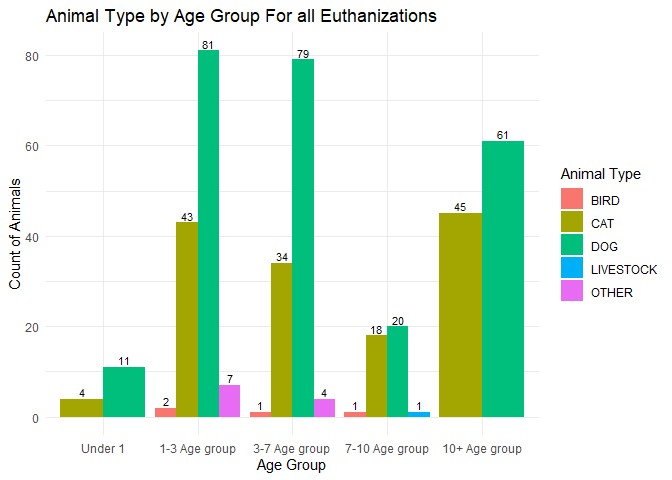

In [ ]:
ggplot(Euthanized, aes(x = Age_group, fill = Animal_Type)) +
  geom_bar(position = "dodge") +
  theme_minimal() +
   geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.9), #Helps align the number in the middle of each bar
    vjust = -0.3, #Helps align the number in the middle of each bar
    size = 3
  ) +
  labs(
    title = "Animal Type by Age Group For all Euthanizations",
    x = "Age Group",
    y = "Count of Animals",
    fill = "Animal Type"
  )

## Creating a new dataframe to get all the animal outcomes in percentage

In [ ]:
summary_data <- combined %>%
  filter(!is.na(Outcome.type.y)) %>%       # remove missing outcomes
  group_by(Outcome.type.y) %>%
  summarise(count = n()) %>%
  mutate(percentage = count / sum(count) * 100)

head(summary_data)

# A tibble: 6 × 3
  Outcome.type.y count percentage
  <chr>          <int>      <dbl>
1 ADOPTION        4250    62.2   
2 DIED              54     0.790 
3 EUTH             713    10.4   
4 FOSTER            49     0.717 
5 RELOCATE           5     0.0731
6 RTO             1108    16.2   

## Creating the third graph- What percentage of animals are adopted vs. euthanized vs. transferred?​

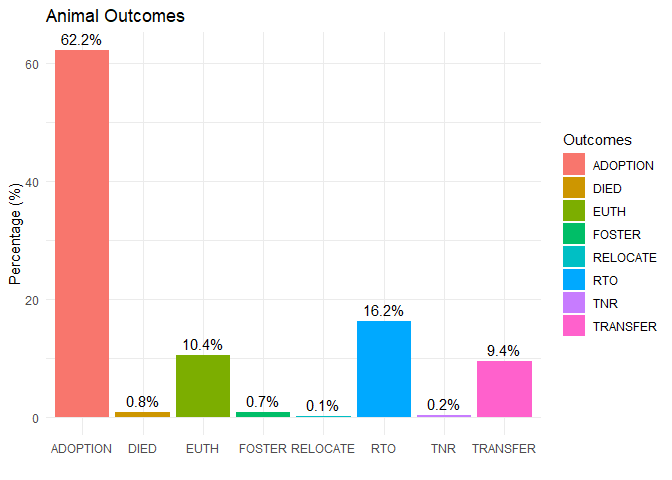

In [ ]:
ggplot(summary_data, aes(x = Outcome.type.y, y = percentage, fill = Outcome.type.y)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(percentage,1), "%")), vjust = -0.5) +
  labs(title = "Animal Outcomes", y = "Percentage (%)", x = "", fill = "Outcomes") +
  theme_minimal()

## Creating a dataframe for the different breeds of animals to remove any NAs

In [ ]:
breed_counts <- combined %>%
  filter(!is.na(Breed)) %>%       
  group_by(Breed) %>%
  summarise(count = n()) %>%
  arrange(desc(count))        

## Creating the Fourth Graph- What are the most common breeds of animals entering the shelter system?​

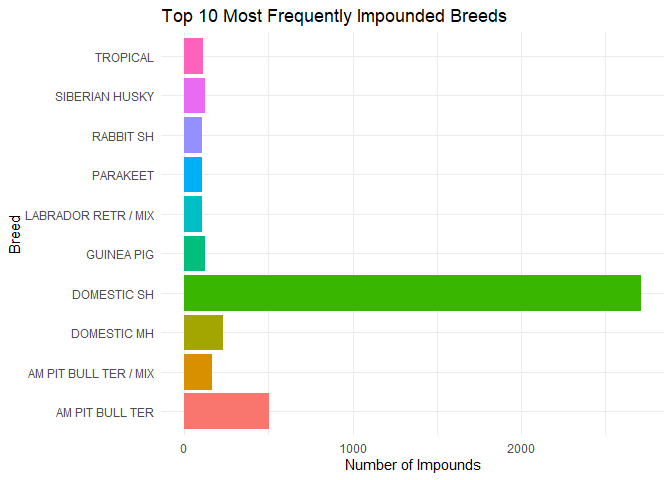

In [ ]:
top_breeds <- breed_counts %>%
  slice_max(count, n = 10)     # pick top 10


ggplot(top_breeds, aes(x = Breed, y = count, fill = Breed)) +
  geom_bar(stat = "identity") +
  coord_flip() +                     
  labs(title = "Top 10 Most Frequently Impounded Breeds",
       x = "Breed",
       y = "Number of Impounds") +
  theme_minimal() +
  theme(legend.position = "none")    # hide legend 

## Just wanted to see the mean number of days that the animals are at the shelter

In [ ]:
mean(combined$StayDays, na.rm = TRUE)

[1] 17.29841

[1] 3.737428

  

## Creating the bite dataframe to remove NAs

In [ ]:
Bite_animal <- combined %>%
  filter(!is.na(Bite_History), Bite_History !="") #Removing NAs and blanks

  
  

## Creating fifth graph- Does the animal bite history affect its outcome?​

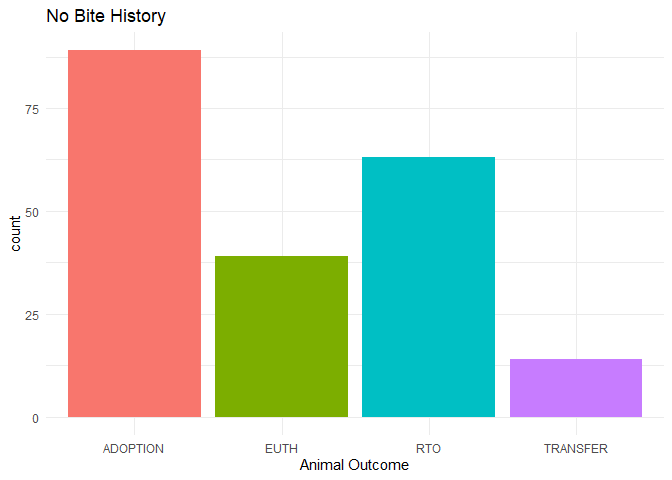

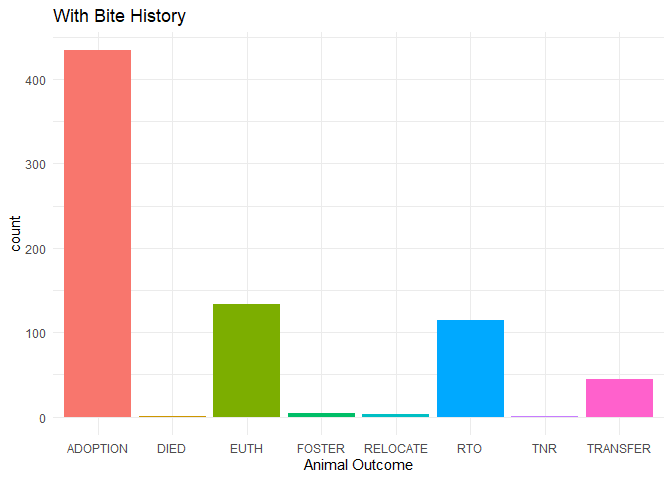

In [ ]:
ggplot(Bite_animal %>% filter(Bite_History == "N"),
                 aes(x = Outcome.type.y, fill = Outcome.type.y)) +
  
  geom_bar() + labs(title = "No Bite History", x = "Animal Outcome") + theme_minimal() + theme(legend.position = "none") 

## Creating the Sixth Graph- How long do animals typically stay in the shelter?

ℹ Please use `linewidth` instead.

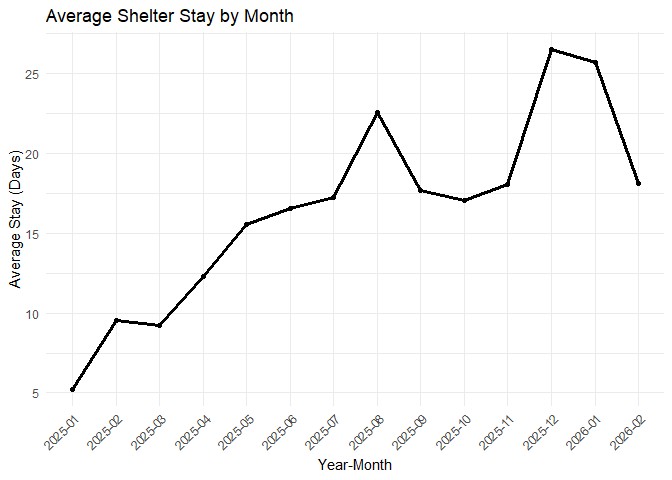

In [ ]:
  Year_month %>%  
  group_by(YearMonth) %>%
  summarise(avg_stay = mean(StayDays, na.rm = TRUE)) %>%
  
  ggplot(aes(x = YearMonth, y = avg_stay, group = 1)) + # Creates a continous line
  geom_line(size = 1.2) +
  geom_point() +
  labs(
    title = "Average Shelter Stay by Month",
    x = "Year-Month",
    y = "Average Stay (Days)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
combined$Adopted <- ifelse(combined$Outcome.type.y == "ADOPTION", 1, 0) ##STar fix
breed_adopt <- combined %>%
  group_by(Breed) %>%
  summarise(
    adoption_rate = mean(Adopted, na.rm = TRUE),
    count = n()
  ) %>%
   filter(count >= 20) %>%
  arrange(desc(adoption_rate)) %>%
  slice_head(n = 10)
breed_adopt$adoption_rate <- as.numeric(breed_adopt$adoption_rate)

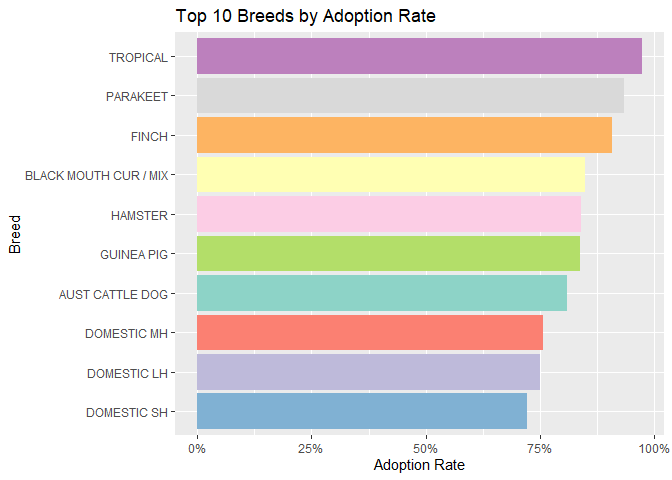

In [ ]:
ggplot(breed_adopt, aes(x = reorder(Breed, adoption_rate), y = adoption_rate, fill = Breed)) +
  geom_col() +
  coord_flip() +
  scale_fill_brewer(palette = "Set3") +
  labs(title = "Top 10 Breeds by Adoption Rate",
       x = "Breed",
       y = "Adoption Rate") +
  scale_y_continuous(labels = scales::percent) +
   theme(legend.position = "none")

In [ ]:
euth_data <- combined %>%
  mutate(Euthanasia = Outcome.type.y == "EUTH") %>%
  group_by(Intake.type) %>%
  summarise(
    total = n(),
    euth_count = sum(Euthanasia, na.rm = TRUE),
    euth_rate = euth_count / total
  )

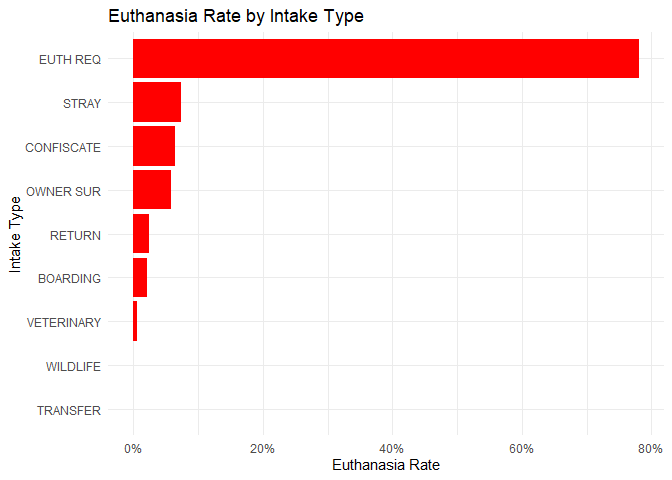

In [ ]:
ggplot(euth_data, aes(x = reorder(Intake.type, euth_rate), y = euth_rate)) +
  geom_col(fill = "red") +
  coord_flip() +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Euthanasia Rate by Intake Type",
       x = "Intake Type",
       y = "Euthanasia Rate") +
  theme_minimal()